<a href="https://colab.research.google.com/github/tezendrax/Machine-Learning-Prac/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SIMPLE SVM IMPLEMENTATION

📊 Dataset Info:
   Positive class samples: 50
   Negative class samples: 50

🔬 Test 1: Standard SVM with C = 1.0
   Accuracy: 100.00%


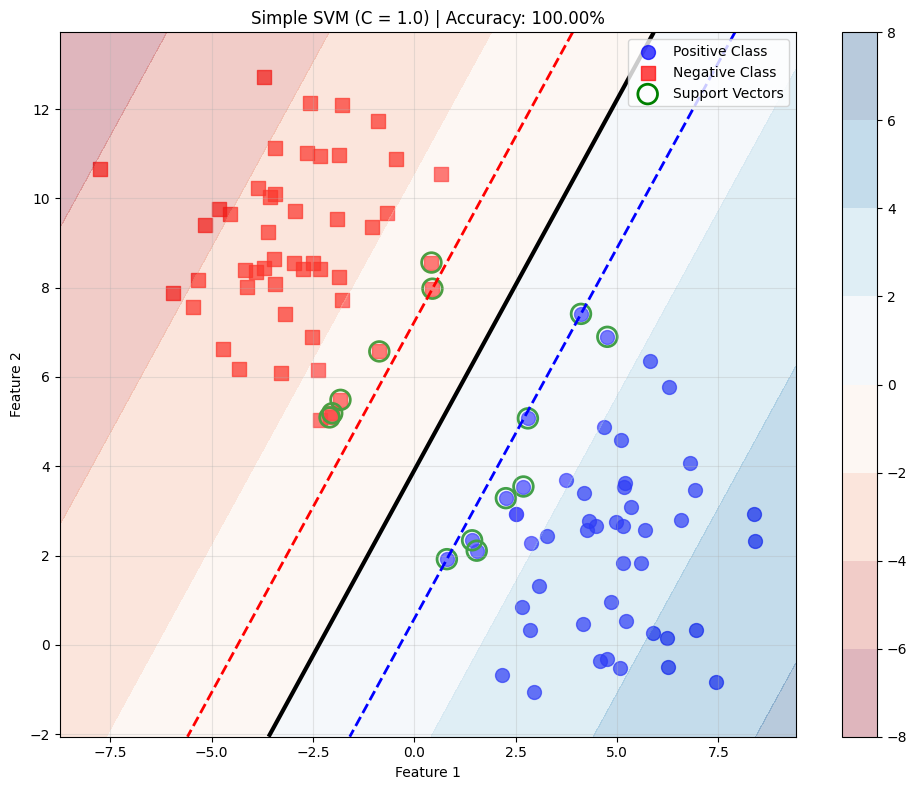


🔬 Test 2: Simple SVM with Small C = 0.1 (More Regularization)
   Accuracy: 100.00%


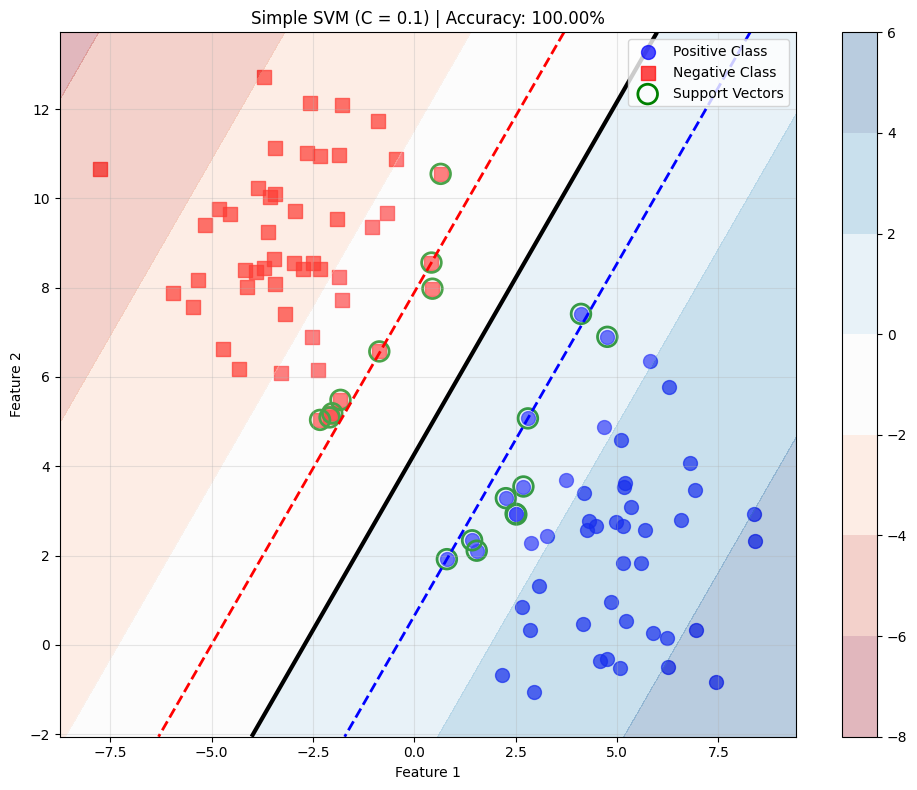


🔬 Test 3: Simple SVM with Large C = 10.0 (Less Regularization)
   Accuracy: 100.00%


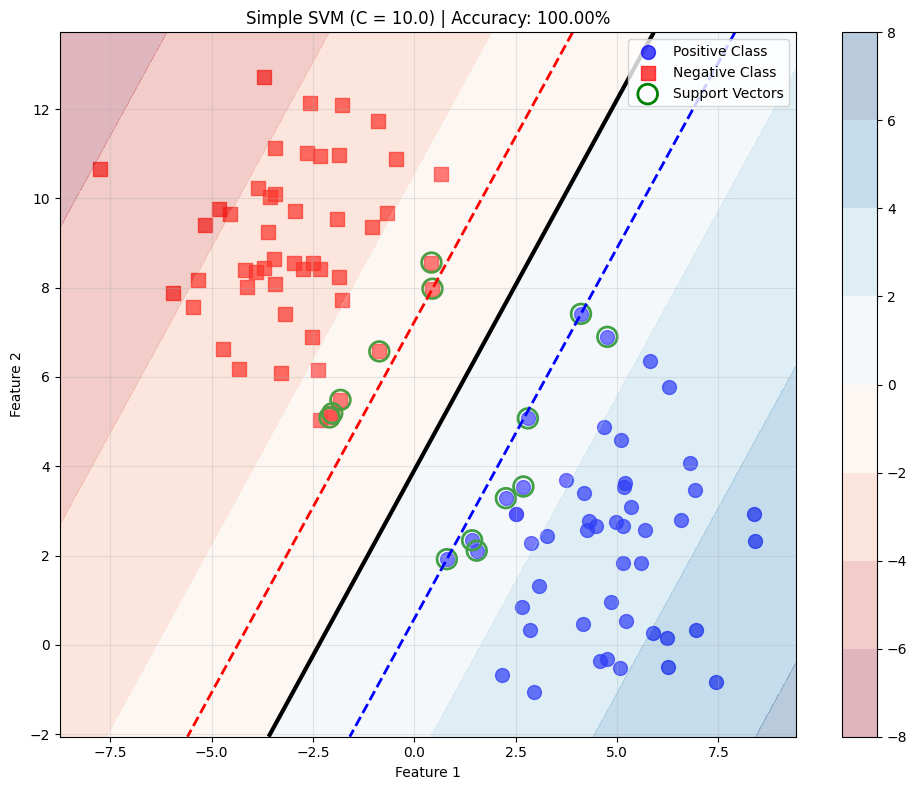

In [3]:
import numpy as np
import cvxopt
import cvxopt.solvers
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

class SimpleSVM:
    """
    A simple SVM implementation (soft margin) using CVXOPT
    """

    def __init__(self, C=1.0):
        self.C = C  # Regularization parameter
        self.w = None
        self.b = None

    def fit(self, X, y):
        """
        Fit a simple SVM using CVXOPT to solve the dual problem
        """
        n_samples, n_features = X.shape

        # Convert y to +1/-1 if not already (and ensure float type)
        y = np.where(y <= 0, -1, 1).astype(float)

        # P matrix (quadratic part of the QP problem)
        # P_ij = y_i * y_j * (x_i . x_j)
        K = X @ X.T  # Linear kernel matrix
        P = cvxopt.matrix(np.outer(y, y) * K)

        # q vector (linear part)
        # q_i = -1 for all i
        q = cvxopt.matrix(-np.ones(n_samples))

        # G matrix for inequality constraints:
        # -alpha_i <= 0  (alpha_i >= 0)
        # alpha_i <= C   (alpha_i - C <= 0)
        G_std = np.diag(-np.ones(n_samples))  # For alpha_i >= 0
        G_slack = np.diag(np.ones(n_samples)) # For alpha_i <= C
        G = cvxopt.matrix(np.vstack((G_std, G_slack)))

        # h vector for inequality constraints
        h_std = np.zeros(n_samples)          # For alpha_i >= 0
        h_slack = np.ones(n_samples) * self.C # For alpha_i <= C
        h = cvxopt.matrix(np.hstack((h_std, h_slack)))

        # A matrix for equality constraint:
        # sum(alpha_i * y_i) = 0
        A = cvxopt.matrix(y, (1, n_samples), 'd')
        b_eq = cvxopt.matrix(0.0)

        # Solve QP problem
        cvxopt.solvers.options['show_progress'] = False
        solution = cvxopt.solvers.qp(P, q, G, h, A, b_eq)

        # Extract Lagrange multipliers (alpha)
        alpha = np.array(solution['x']).flatten()

        # Compute w = sum(alpha_i * y_i * x_i)
        self.w = np.sum([alpha[i] * y[i] * X[i] for i in range(n_samples)], axis=0)

        # Compute b using support vectors (where 0 < alpha_i < C)
        # For a support vector, y_k(w.x_k + b) = 1 => b = y_k - w.x_k
        tol = 1e-5
        sv_indices = np.where((alpha > tol) & (alpha < self.C - tol))[0]

        if len(sv_indices) > 0:
            b_candidates = []
            for i in sv_indices:
                b_candidates.append(y[i] - np.dot(self.w, X[i]))
            self.b = np.mean(b_candidates)
        else:
            # If no support vectors strictly between 0 and C, take any alpha > 0
            # This can happen in perfectly separable cases or extreme C values.
            sv_indices = np.where(alpha > tol)[0]
            if len(sv_indices) > 0:
                # Pick an arbitrary support vector for b calculation
                i = sv_indices[0]
                self.b = y[i] - np.dot(self.w, X[i])
            else:
                self.b = 0 # Fallback if no support vectors found (unlikely for solvable QP)

        return self

    def predict(self, X):
        """Predict class labels"""
        decision = np.dot(X, self.w) + self.b
        return np.sign(decision)

    def decision_function(self, X):
        """Raw decision function values"""
        return np.dot(X, self.w) + self.b

# DEMONSTRATION

def generate_data(n_samples=100, separable=True):
    """Generate synthetic data with different margins"""
    # If separable is False, create more overlapping clusters to demonstrate soft margin
    X, y = make_blobs(n_samples=n_samples, centers=2,
                      cluster_std=1.0 if separable else 2.0,
                      random_state=42)
    y = np.where(y == 0, -1, 1)
    return X, y

def plot_results(X, y, model, title):
    """Plot the SVM decision boundary and margins"""
    plt.figure(figsize=(10, 8))

    # Plot data points
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
               c='blue', marker='o', label='Positive Class', s=100, alpha=0.7)
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1],
               c='red', marker='s', label='Negative Class', s=100, alpha=0.7)

    # Create mesh for decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Predict on mesh
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary (Z=0) and margins (Z=1, Z=-1)
    plt.contour(xx, yy, Z, levels=[-1, 0, 1],
               colors=['red', 'black', 'blue'],
               linestyles=['--', '-', '--'],
               linewidths=[2, 3, 2])

    # Highlight support vectors (approximate: points close to the margin)
    decision_values = model.decision_function(X)
    # Support vectors are points for which |decision_function| is close to 1
    support_vector_mask = (np.abs(decision_values - 1) < 0.5) | \
                          (np.abs(decision_values + 1) < 0.5)

    plt.scatter(X[support_vector_mask, 0], X[support_vector_mask, 1],
               s=200, facecolors='none', edgecolors='green',
               linewidths=2, label='Support Vectors')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.colorbar(plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu'))
    plt.tight_layout()
    plt.show()

# RUNNING EXPERIMENTS


if __name__ == "__main__":
    print("="*60)
    print("SIMPLE SVM IMPLEMENTATION")
    print("="*60)

    # Generate data (making it non-separable to better demonstrate soft margin)
    X, y = generate_data(n_samples=100, separable=False)

    print(f"\n📊 Dataset Info:")
    print(f"   Positive class samples: {np.sum(y == 1)}")
    print(f"   Negative class samples: {np.sum(y == -1)}")

    # Test 1: Standard C (C=1.0)
    print("\n🔬 Test 1: Standard SVM with C = 1.0")
    svm_standard = SimpleSVM(C=1.0)
    svm_standard.fit(X, y)

    y_pred_standard = svm_standard.predict(X)
    accuracy_standard = np.mean(y_pred_standard == y) * 100
    print(f"   Accuracy: {accuracy_standard:.2f}%")

    plot_results(X, y, svm_standard,
                f"Simple SVM (C = 1.0) | Accuracy: {accuracy_standard:.2f}%")

    # Test 2: Small C (more regularization, wider margin, more misclassifications)
    print("\n🔬 Test 2: Simple SVM with Small C = 0.1 (More Regularization)")
    svm_small_c = SimpleSVM(C=0.1)
    svm_small_c.fit(X, y)

    y_pred_small_c = svm_small_c.predict(X)
    accuracy_small_c = np.mean(y_pred_small_c == y) * 100
    print(f"   Accuracy: {accuracy_small_c:.2f}%")

    plot_results(X, y, svm_small_c,
                f"Simple SVM (C = 0.1) | Accuracy: {accuracy_small_c:.2f}%")

    # Test 3: Large C (less regularization, narrower margin, fewer misclassifications if possible)
    print("\n🔬 Test 3: Simple SVM with Large C = 10.0 (Less Regularization)")
    svm_large_c = SimpleSVM(C=10.0)
    svm_large_c.fit(X, y)

    y_pred_large_c = svm_large_c.predict(X)
    accuracy_large_c = np.mean(y_pred_large_c == y) * 100
    print(f"   Accuracy: {accuracy_large_c:.2f}%")

    plot_results(X, y, svm_large_c,
                f"Simple SVM (C = 10.0) | Accuracy: {accuracy_large_c:.2f}%")


### Experiment with Perfectly Separable Data

Let's see how the `SimpleSVM` performs on a perfectly linearly separable dataset. In this scenario, we expect a clear decision boundary and margins with few, if any, misclassifications, even with moderate `C` values.


📊 Perfectly Separable Dataset Info:
   Positive class samples: 50
   Negative class samples: 50

🔬 Training SVM on Separable Data (C = 1.0)
   Accuracy: 100.00%


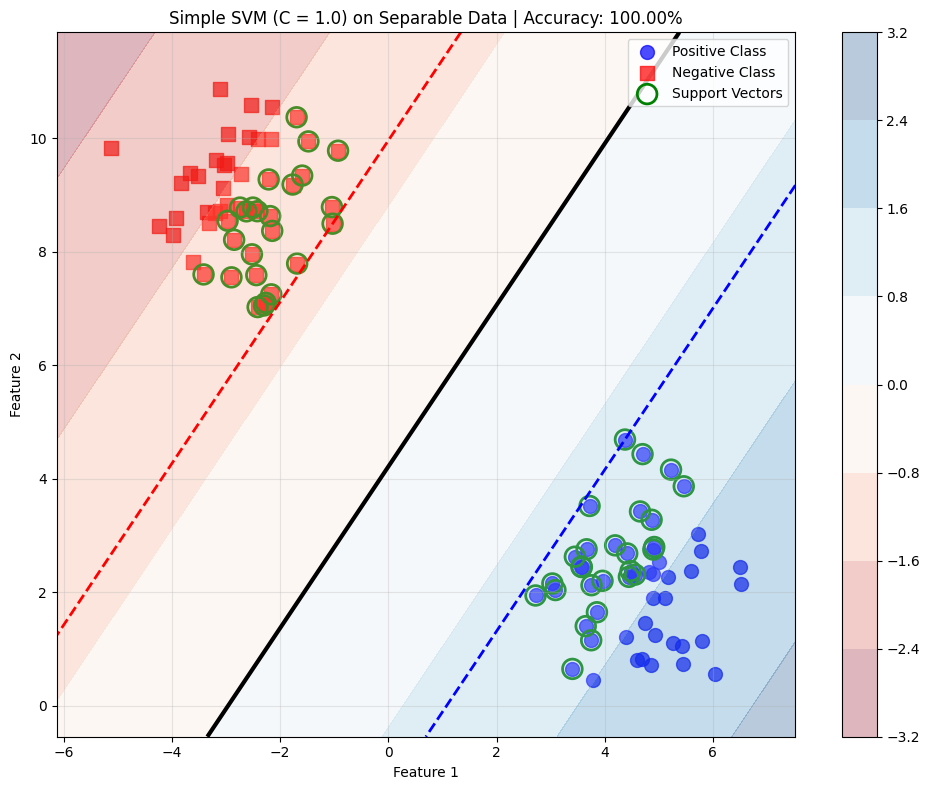

In [4]:
# Generate perfectly separable data
X_sep, y_sep = generate_data(n_samples=100, separable=True)

print(f"\n📊 Perfectly Separable Dataset Info:")
print(f"   Positive class samples: {np.sum(y_sep == 1)}")
print(f"   Negative class samples: {np.sum(y_sep == -1)}")

# Fit SimpleSVM with standard C=1.0
print("\n🔬 Training SVM on Separable Data (C = 1.0)")
svm_separable = SimpleSVM(C=1.0)
svm_separable.fit(X_sep, y_sep)

y_pred_separable = svm_separable.predict(X_sep)
accuracy_separable = np.mean(y_pred_separable == y_sep) * 100
print(f"   Accuracy: {accuracy_separable:.2f}%")

plot_results(X_sep, y_sep, svm_separable,
             f"Simple SVM (C = 1.0) on Separable Data | Accuracy: {accuracy_separable:.2f}%")